# 🧬 Biomedical Research Abstracts 2024–2026
### Data Science Notebook | Full Analysis Pipeline

**Dataset:** 126,832 cleaned biomedical abstracts · PubMed/NCBI · Jan 2024 – Mar 2026  
**Modules:** Abstract Search & NLP · Topic Trends · Country & Journal Insights · Open Access Analysis

---
**Sections:**
1. [Setup & Data Loading](#1-setup)
2. [Exploratory Data Analysis](#2-eda)
3. [Abstract Search & NLP](#3-nlp)
4. [Topic & Keyword Trends](#4-topics)
5. [Country & Journal Insights](#5-geo)
6. [Open Access Analysis](#6-oa)
7. [Machine Learning | Multi-label Classification](#7-ml)
8. [Semantic Search with FAISS](#8-faiss)
9. [Temporal Trend Analysis](#9-temporal)
10. [Export & Summary](#10-export)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [4]:


!pip install pandas numpy matplotlib seaborn plotly scikit-learn
!pip install nltk wordcloud textblob
!pip install sentence-transformers faiss-cpu
!pip install bertopic umap-learn hdbscan


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.0 MB/s eta 0:00:00


In [5]:
#  Core imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import os
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 120)

# Consistent plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#3266ad', '#1D9E75', '#7F77DD', '#BA7517', '#D85A30', '#888780']
sns.set_palette(PALETTE)

print(' Core libraries loaded')

 Core libraries loaded


In [6]:

CSV_PATH = '/kaggle/input/datasets/kanchana1990/biomedical-research-abstracts-20242026/biomedical_research_abstracts_2024_2026.csv'   # ← update path as needed

df = pd.read_csv(CSV_PATH, low_memory=False)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (126832, 17)
Columns: ['pmid', 'title', 'abstract', 'abstract_words', 'journal', 'pub_year', 'pub_month', 'pub_month_num', 'month_year', 'doi', 'authors_count', 'country', 'research_type', 'keywords', 'major_topic', 'language', 'open_access']


In [7]:
#  Data types & quick peek ─
df.dtypes

pmid               int64
title             object
abstract          object
abstract_words     int64
journal           object
pub_year           int64
pub_month         object
pub_month_num      int64
month_year        object
doi               object
authors_count      int64
country           object
research_type     object
keywords          object
major_topic       object
language          object
open_access         bool
dtype: object

In [8]:
df.head(3)

,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access
0,41869676,"The genome sequence of the bloodfluke planorb, Biomphalaria glabrata NIMR strain (Say, 1818).",We present a genome assembly from an individual Biomphalaria glabrata NIMR strain (bloodfluke planorb; Mollusca; Gas...,57,Wellcome open research,2024,Unknown,0,Unknown-2024,10.12688/wellcomeopenres.22819.2,7,UK,Journal Article,NaN,NaN,eng,True
1,41841041,An exploratory study of critical incidents within public organizations during leadership change.,Leadership changes within public organizations are often associated with achieving the organization's vision. This e...,250,F1000Research,2024,Unknown,0,Unknown-2024,10.12688/f1000research.142942.2,4,Indonesia,Journal Article,Leadership; Humans; Anxiety; Organizational Innovation; Organizational Culture; Female; Male,Leadership,eng,True
2,41797731,From Mary Shelley to Netflix: a Pan-European perspective on public communication of neuroscience and neurotechnology.,Scientific knowledge of the human brain has captivated the public's attention and sparked their imagination for cent...,244,Frontiers in neuroscience,2024,Unknown,0,Unknown-2024,10.3389/fnins.2024.1278640,2,Spain,Journal Article,NaN,NaN,eng,True


In [9]:
#  Type coercion & cleaning 
df['pub_year']       = pd.to_numeric(df['pub_year'], errors='coerce').astype('Int64')
df['pub_month_num']  = pd.to_numeric(df['pub_month_num'], errors='coerce').astype('Int64')
df['abstract_words'] = pd.to_numeric(df['abstract_words'], errors='coerce').astype('Int64')
df['authors_count']  = pd.to_numeric(df['authors_count'], errors='coerce').astype('Int64')
df['open_access']    = df['open_access'].astype(bool)

# Parse month-year as datetime for time series
df['date'] = pd.to_datetime(
    df['pub_year'].astype(str) + '-' + df['pub_month_num'].astype(str).str.zfill(2),
    format='%Y-%m', errors='coerce'
)

# Normalise text fields
for col in ['title', 'abstract', 'journal', 'country', 'research_type', 'major_topic']:
    df[col] = df[col].fillna('').astype(str).str.strip()

print(' Types coerced. Nulls per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

 Types coerced. Nulls per column:
doi           934
keywords    60073
date        20666
dtype: int64


---
## 2. Exploratory Data Analysis <a id='2-eda'></a>

In [10]:
#  Summary statistics 
print('=== Dataset Summary ===')
print(f"  Total abstracts : {len(df):,}")
print(f"  Date range      : {df['date'].min().strftime('%b %Y')} – {df['date'].max().strftime('%b %Y')}")
print(f"  Unique journals : {df['journal'].nunique():,}")
print(f"  Unique countries: {df['country'].nunique():,}")
print(f"  Open access     : {df['open_access'].mean()*100:.1f}%")
print(f"  Avg words       : {df['abstract_words'].mean():.0f} (std={df['abstract_words'].std():.0f})")
print(f"  Avg authors     : {df['authors_count'].mean():.1f}")

=== Dataset Summary ===
  Total abstracts : 126,832
  Date range      : Jan 2024 – Mar 2026
  Unique journals : 7,249
  Unique countries: 22,336
  Open access     : 65.8%
  Avg words       : 224 (std=71)
  Avg authors     : 7.2


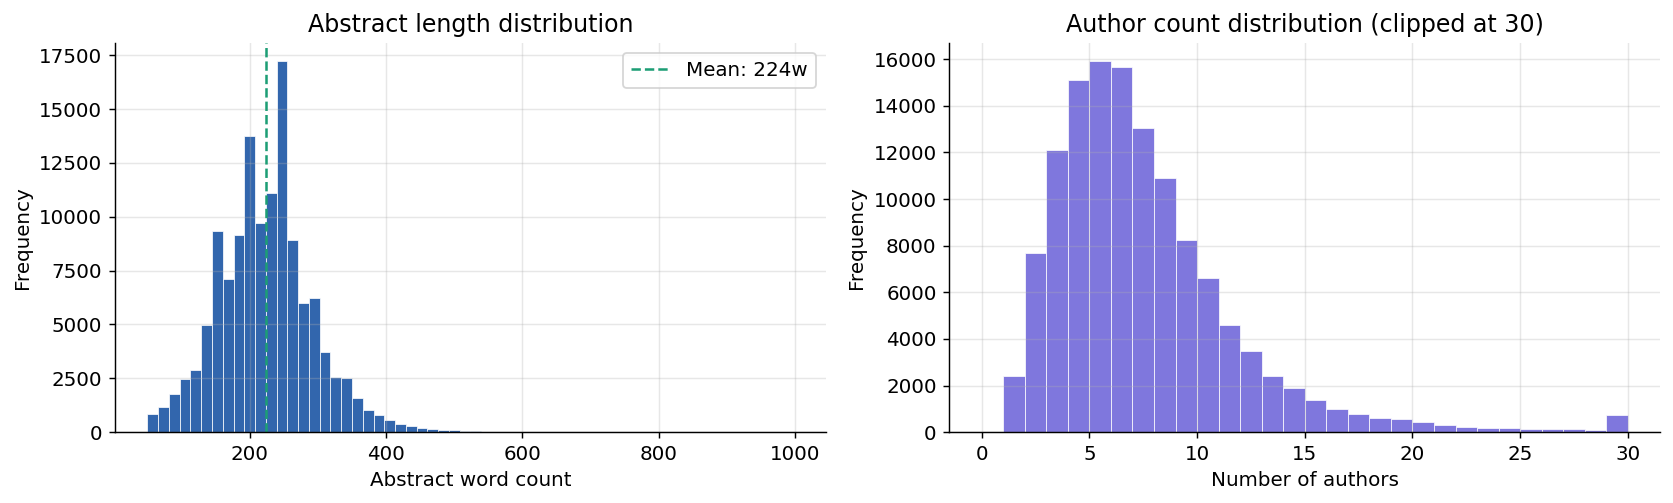

In [11]:
#  Abstract length distribution ─
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['abstract_words'].dropna(), bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Abstract word count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Abstract length distribution')
axes[0].axvline(df['abstract_words'].mean(), color=PALETTE[1], linestyle='--', linewidth=1.4, label=f"Mean: {df['abstract_words'].mean():.0f}w")
axes[0].legend()

axes[1].hist(df['authors_count'].dropna().clip(upper=30), bins=30, color=PALETTE[2], edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Number of authors')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Author count distribution (clipped at 30)')

plt.tight_layout()
plt.show()

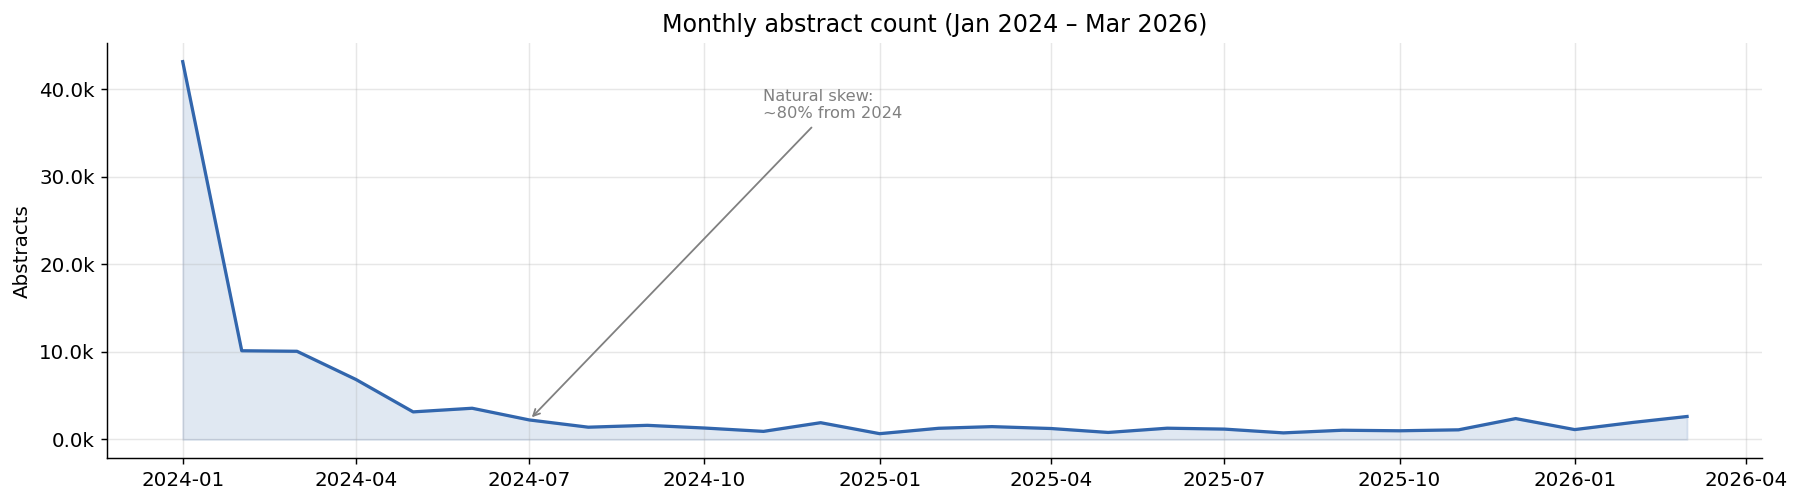

In [12]:
#  Monthly publication volume 
monthly = df.groupby('date').size().reset_index(name='count').sort_values('date')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['date'], monthly['count'], alpha=0.15, color=PALETTE[0])
ax.plot(monthly['date'], monthly['count'], color=PALETTE[0], linewidth=1.8)
ax.set_title('Monthly abstract count (Jan 2024 – Mar 2026)')
ax.set_ylabel('Abstracts')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
ax.annotate('Natural skew:\n~80% from 2024', xy=(monthly['date'].iloc[6], monthly['count'].iloc[6]),
            xytext=(monthly['date'].iloc[10], monthly['count'].max()*0.85),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
plt.tight_layout()
plt.show()

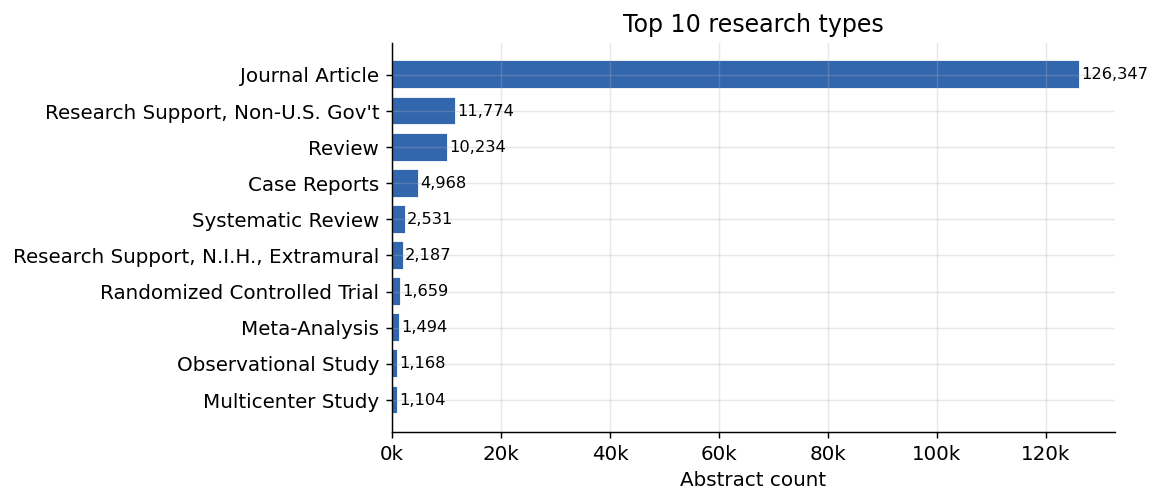

In [13]:
#  Research type distribution 

# research_type may contain multiple types separated by ';' | explode to get counts
type_series = df['research_type'].str.split(';').explode().str.strip()
type_counts = type_series[type_series != ''].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1], color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Abstract count')
ax.set_title('Top 10 research types')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar, val in zip(bars, type_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

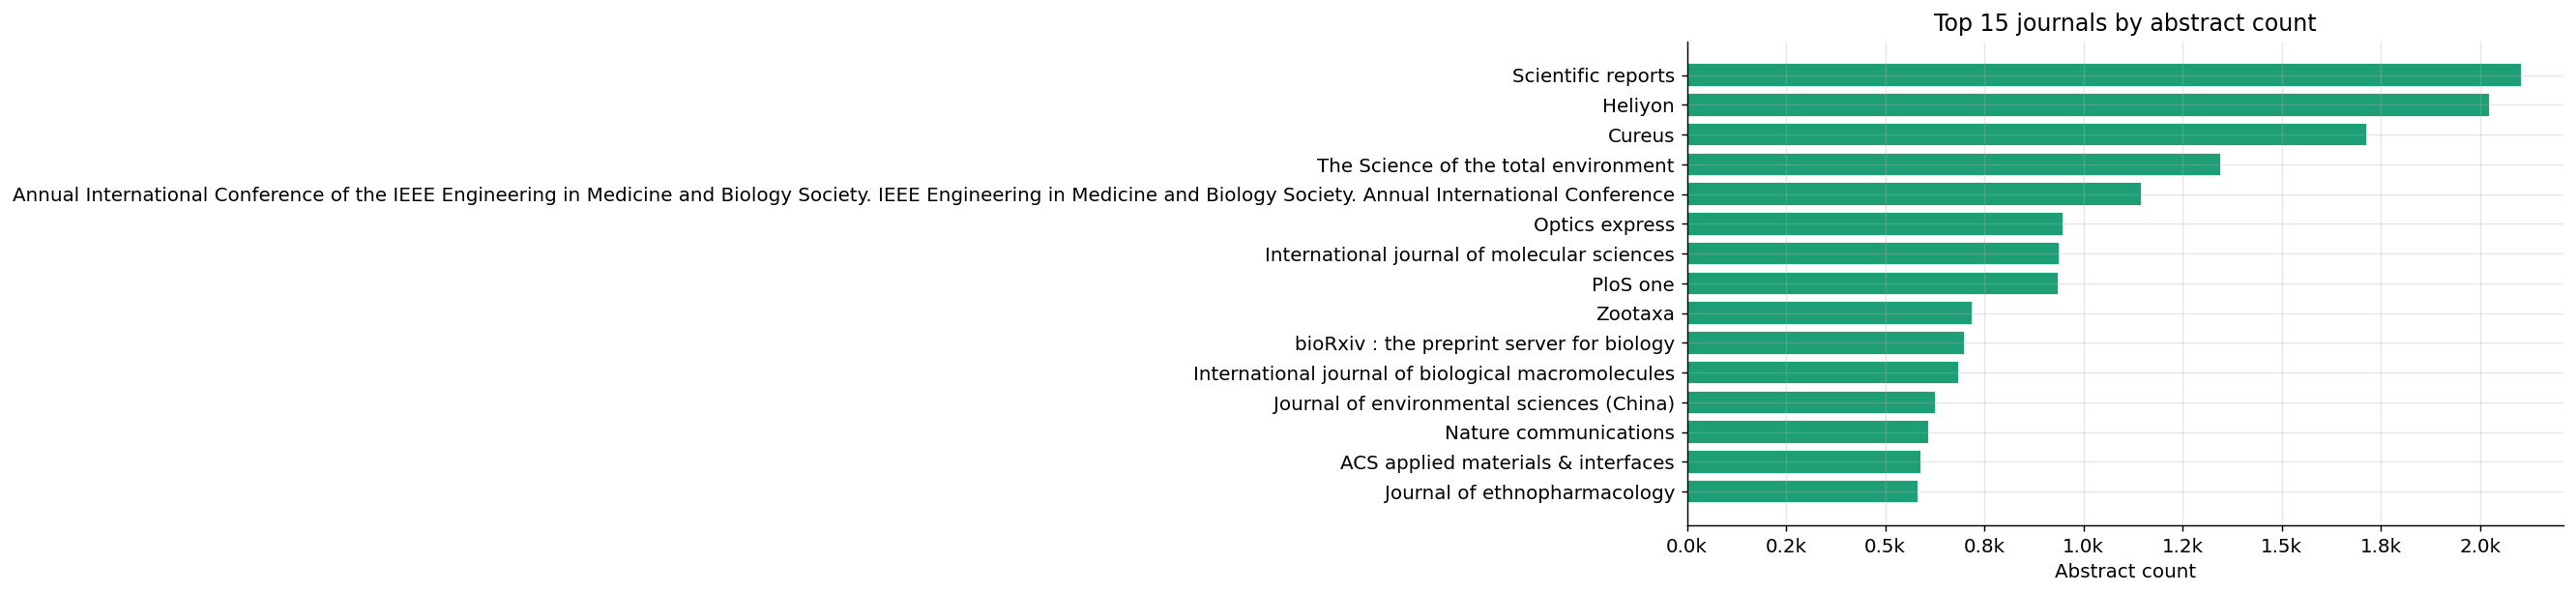

In [14]:
#  Top 15 journals 
top_journals = df['journal'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top_journals.index[::-1], top_journals.values[::-1], color=PALETTE[1], edgecolor='white')
ax.set_xlabel('Abstract count')
ax.set_title('Top 15 journals by abstract count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
plt.tight_layout()
plt.show()

---
## 3. Abstract Search & NLP <a id='3-nlp'></a>

In [15]:
#  Keyword search function 
def search_abstracts(query, field='all', top_n=10, year=None, open_access_only=False):
    """
    Search abstracts by keyword.
    
    Parameters
    ----------
    query : str  | search term(s), supports | for OR, & for AND
    field : str  | 'all', 'title', 'abstract', 'keywords'
    top_n : int  | number of results to return
    year  : int  | filter by publication year (optional)
    open_access_only : bool
    """
    tmp = df.copy()
    if year:
        tmp = tmp[tmp['pub_year'] == year]
    if open_access_only:
        tmp = tmp[tmp['open_access'] == True]

    field_map = {
        'title'    : tmp['title'],
        'abstract' : tmp['abstract'],
        'keywords' : tmp['keywords'],
        'all'      : tmp['title'] + ' ' + tmp['abstract'] + ' ' + tmp['keywords'],
    }
    haystack = field_map.get(field, field_map['all']).str.lower()

    # Support OR / AND operators
    if '|' in query:
        terms = [t.strip() for t in query.split('|')]
        mask  = haystack.str.contains('|'.join(re.escape(t) for t in terms), na=False)
    elif '&' in query:
        terms = [t.strip() for t in query.split('&')]
        mask  = pd.Series([True]*len(haystack), index=haystack.index)
        for t in terms:
            mask &= haystack.str.contains(re.escape(t), na=False)
    else:
        mask = haystack.str.contains(re.escape(query.lower()), na=False)

    results = tmp[mask][['pmid','title','journal','pub_year','pub_month',
                          'research_type','country','open_access','abstract_words',
                          'major_topic','abstract']].head(top_n)
    print(f'Found {mask.sum():,} matches | showing top {min(top_n, mask.sum())}')
    return results


# Example searches
results = search_abstracts('CRISPR', field='all', top_n=5)
results[['title','journal','pub_year','country','open_access']]

Found 394 matches | showing top 5


,title,journal,pub_year,country,open_access
974,A Single-Copy Sensitive and Field-Deployable One-Pot RT-RPA CRISPR/Cas12a Assay for the Specific Visual Detection of...,Transboundary and emerging diseases,2024,China,True
1045,"Palm Multidiagnostic of Mycoplasma pneumoniae, Chlamydia pneumoniae, Haemophilus influenzae, and Streptococcus pneum...",Transboundary and emerging diseases,2024,Zhejiang Lab Hangzhou 311121China,True
2386,CRISPR/Cas9-edited duck enteritis virus expressing Pmp17G of Chlamydia psittaci induced protective immunity in duckl...,Pathogens and disease,2024,China,True
2639,A genome-wide CRISPR screen identifies BRD4 as a regulator of cardiomyocyte differentiation.,Nature cardiovascular research,2024,USA arunpadmanabhan@gladstoneucsfedu,True
9599,Multiple nucleic acids testing on a low-cost digital microfluidic platform for respiratory bacteria (MNAT-DMF).,Annual International Conference of the IEEE Engineering in Medicine and Biology Society. IEEE Engineering in Medicin...,2024,Unknown,False


In [16]:
#  Boolean search example ─
results_and = search_abstracts('machine learning & cancer', field='all', top_n=5)
results_and[['title','journal','pub_year','country']]

Found 192 matches | showing top 5


,title,journal,pub_year,country
24,ProtoBERT-LoRA: Parameter-Efficient Prototypical Finetuning for Immunotherapy Study Identification.,AMIA ... Annual Symposium proceedings. AMIA Symposium,2024,MD
84,Adjusting Covariate Misclassification in Electronic Health Records-Based Machine Learning Prediction Models.,AMIA ... Annual Symposium proceedings. AMIA Symposium,2024,USA
99,Automating Lung-RADS Categorization And Follow-Up Recommendations Using In-Context Learning With Large Language Models.,AMIA ... Annual Symposium proceedings. AMIA Symposium,2024,USA
122,DGSurv: Dynamic Graph-Based Multimodal Learning for Interpretable Cancer Survival Prediction.,AMIA ... Annual Symposium proceedings. AMIA Symposium,2024,USA
720,Preemptive Forecasting of Symptom Escalation in Cancer Patients Undergoing Chemotherapy.,AMIA ... Annual Symposium proceedings. AMIA Symposium,2024,USA


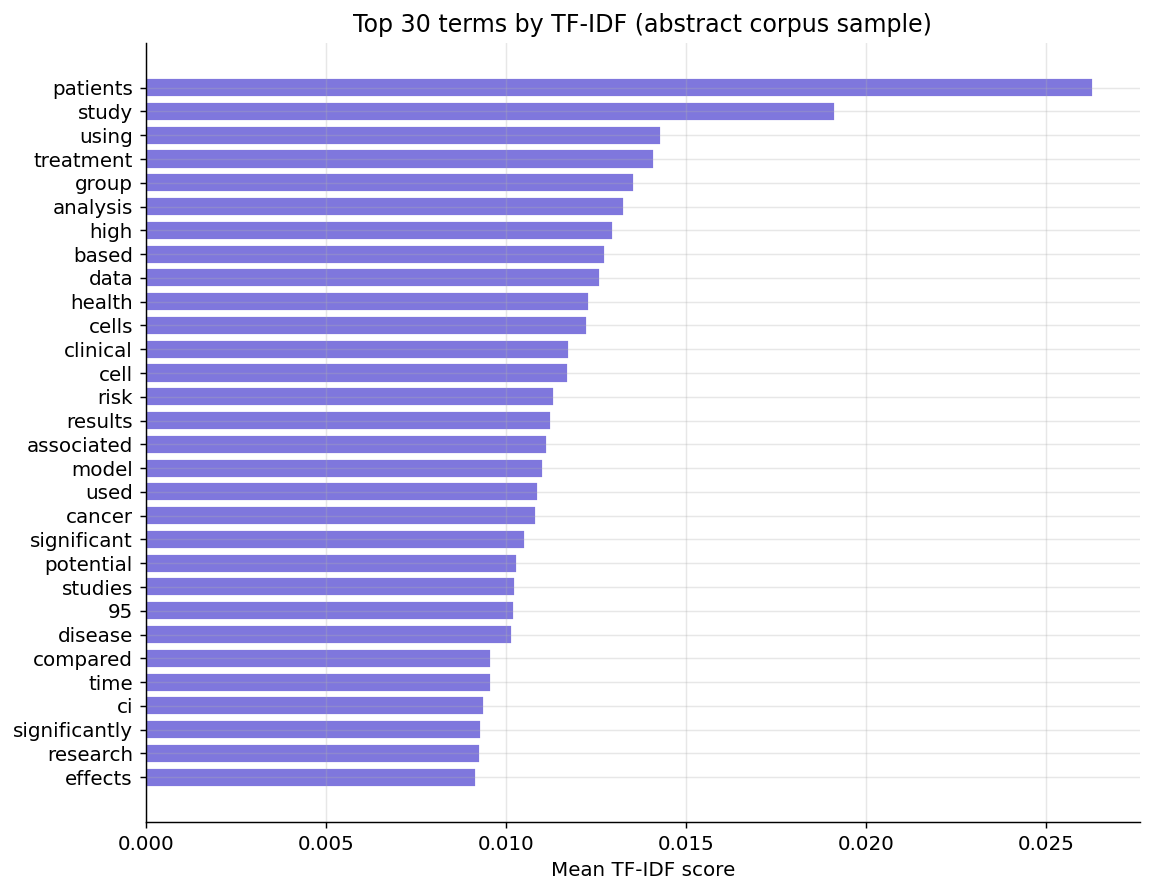

 TF-IDF matrix shape: (20000, 5000)


In [17]:
#  TF-IDF keyword extraction ─
from sklearn.feature_extraction.text import TfidfVectorizer

sample_size = min(20000, len(df))
sample_df   = df.sample(sample_size, random_state=42)

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=10
)

X_tfidf = tfidf.fit_transform(sample_df['abstract'])
feature_names = tfidf.get_feature_names_out()

# Top terms by mean TF-IDF score
mean_tfidf   = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx      = mean_tfidf.argsort()[::-1][:30]
top_terms_df = pd.DataFrame({'term': feature_names[top_idx], 'mean_tfidf': mean_tfidf[top_idx]})

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_terms_df['term'][::-1], top_terms_df['mean_tfidf'][::-1], color=PALETTE[2], edgecolor='white')
ax.set_xlabel('Mean TF-IDF score')
ax.set_title('Top 30 terms by TF-IDF (abstract corpus sample)')
plt.tight_layout()
plt.show()

print(' TF-IDF matrix shape:', X_tfidf.shape)

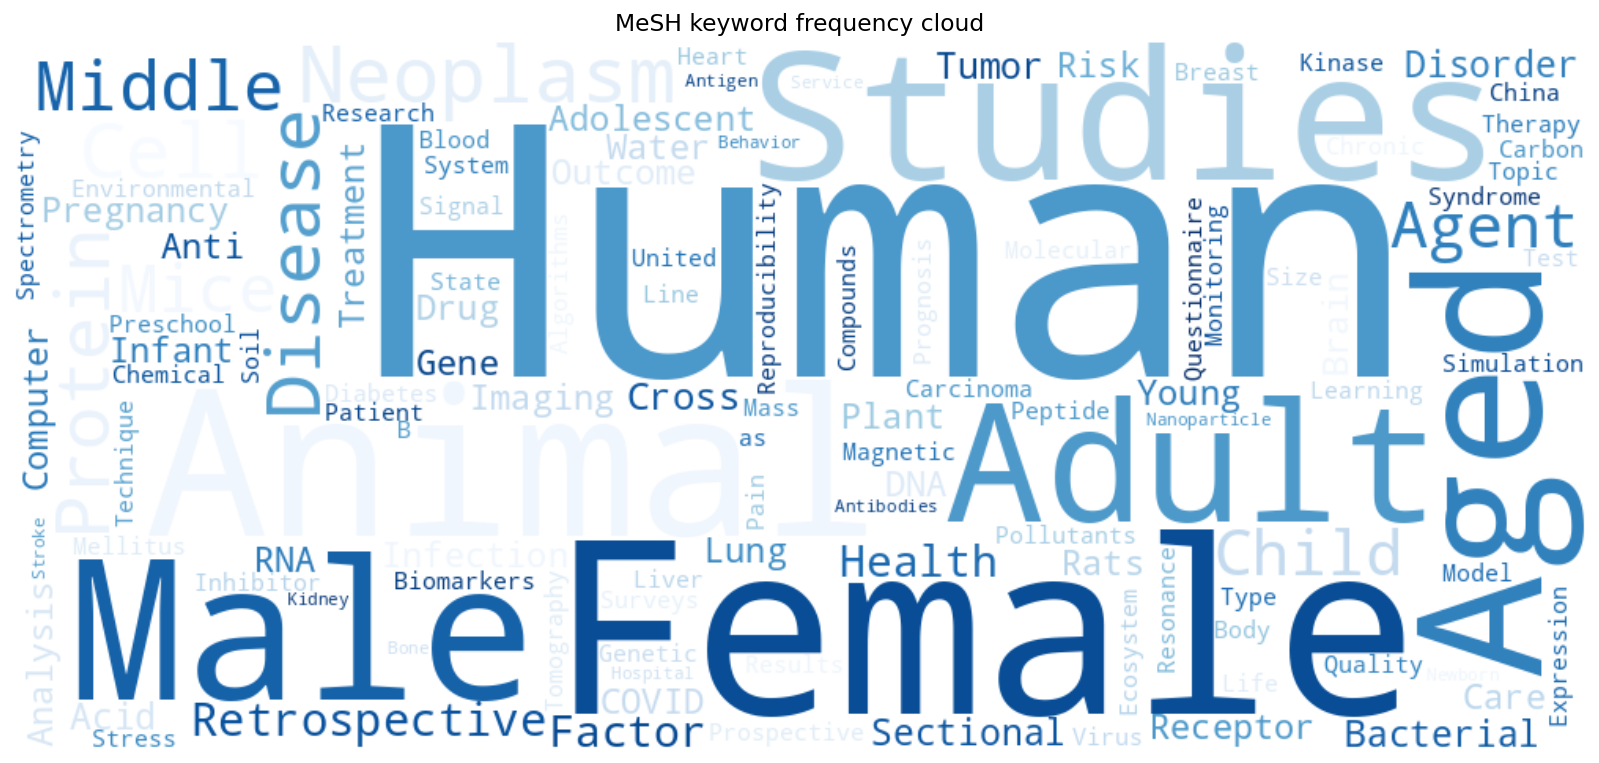

In [18]:
#  Word cloud of top MeSH keywords 
try:
    from wordcloud import WordCloud

    all_kw = ' '.join(df['keywords'].fillna('').tolist())
    # Remove common separators and empty values
    all_kw = re.sub(r'[;,]', ' ', all_kw)

    wc = WordCloud(
        width=1000, height=450,
        background_color='white',
        colormap='Blues',
        max_words=120,
        stopwords={'and','or','of','the','in','with','a','to','for','from','by','an'},
        collocations=False
    ).generate(all_kw)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('MeSH keyword frequency cloud', fontsize=13)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('WordCloud not installed. Run: pip install wordcloud')

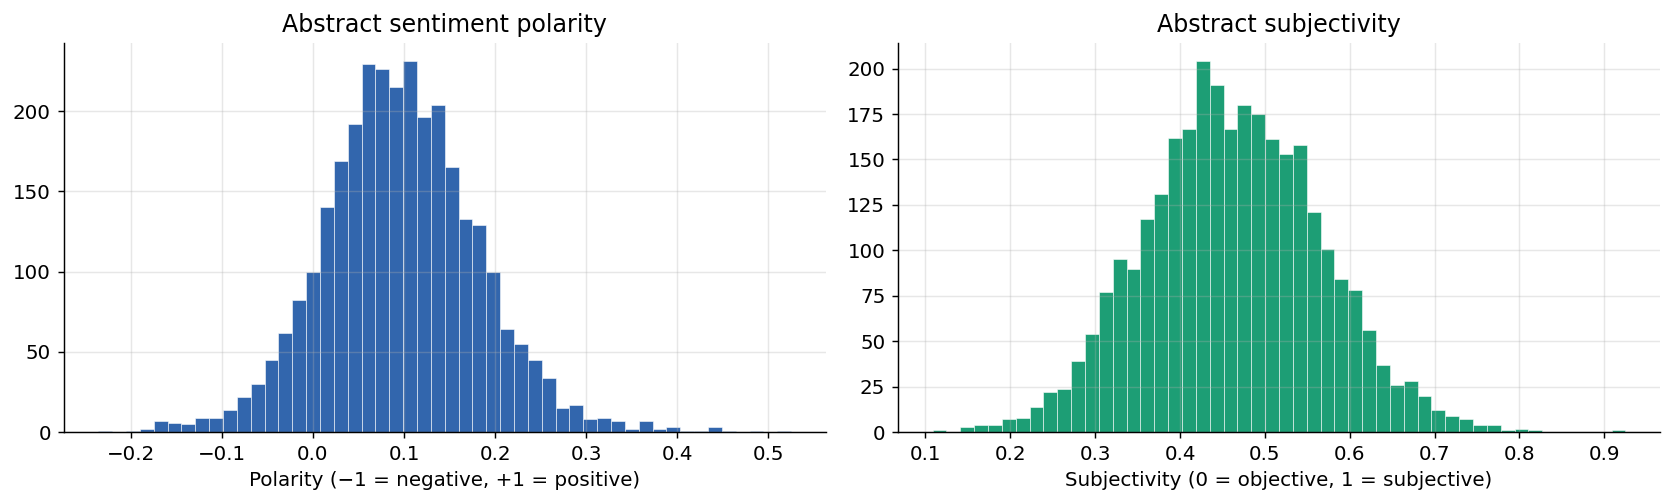

Mean polarity: 0.0965 | Mean subjectivity: 0.4621


In [19]:
# Sentiment / readability proxy (TextBlob) 
try:
    from textblob import TextBlob

    sample = df.sample(3000, random_state=42).copy()
    sample['polarity']     = sample['abstract'].apply(lambda x: TextBlob(x).sentiment.polarity)
    sample['subjectivity'] = sample['abstract'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(sample['polarity'], bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.3)
    axes[0].set_title('Abstract sentiment polarity')
    axes[0].set_xlabel('Polarity (−1 = negative, +1 = positive)')

    axes[1].hist(sample['subjectivity'], bins=50, color=PALETTE[1], edgecolor='white', linewidth=0.3)
    axes[1].set_title('Abstract subjectivity')
    axes[1].set_xlabel('Subjectivity (0 = objective, 1 = subjective)')

    plt.tight_layout()
    plt.show()
    print(f"Mean polarity: {sample['polarity'].mean():.4f} | Mean subjectivity: {sample['subjectivity'].mean():.4f}")
except ImportError:
    print('TextBlob not installed. Run: pip install textblob')

---
## 4. Topic & Keyword Trends <a id='4-topics'></a>

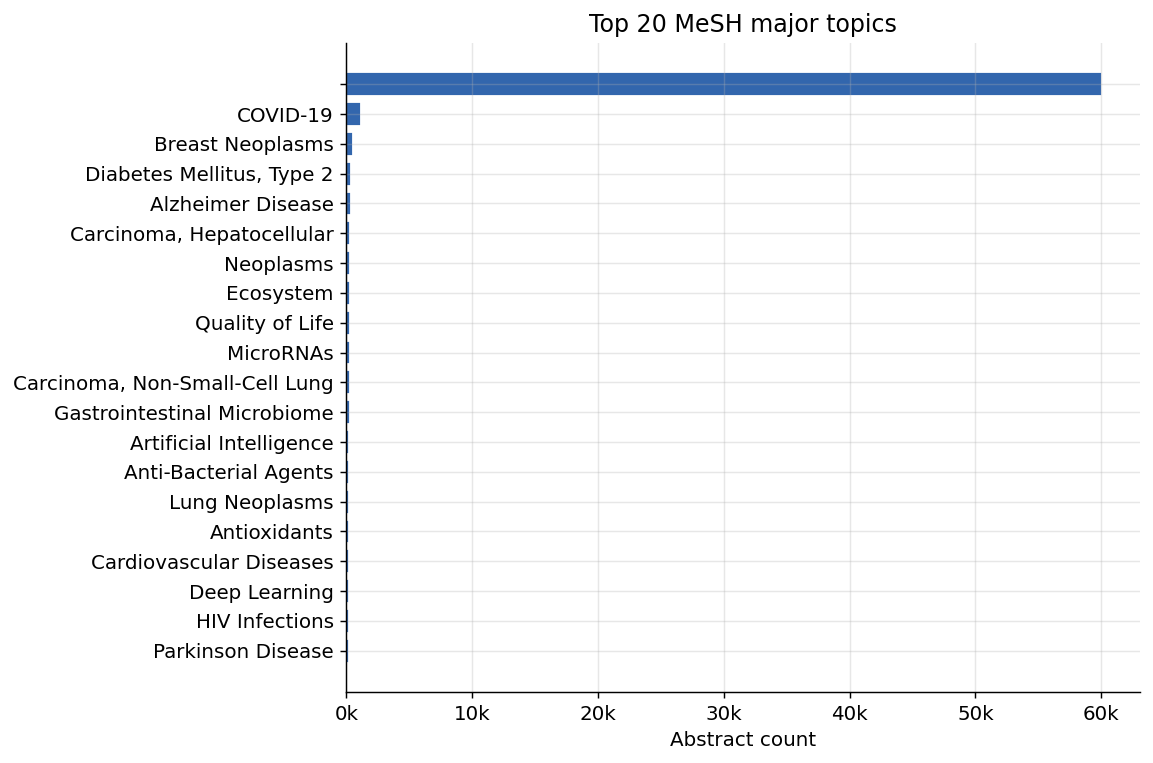

In [20]:
#  Top MeSH major topics 
top_topics = df['major_topic'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_topics.index[::-1], top_topics.values[::-1], color=PALETTE[0], edgecolor='white')
ax.set_xlabel('Abstract count')
ax.set_title('Top 20 MeSH major topics')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

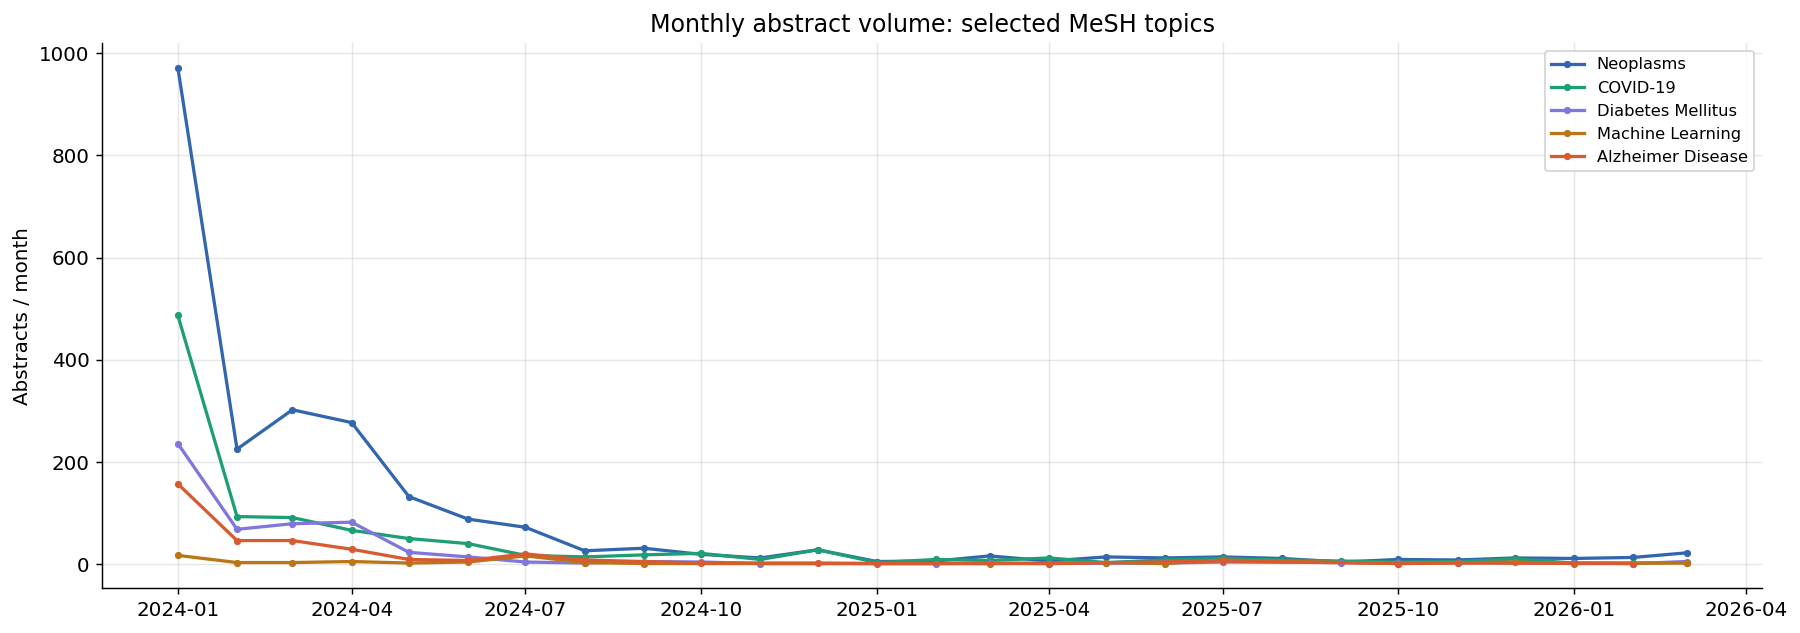

In [21]:
#  Monthly trend for selected topics 
TRACK_TOPICS = ['Neoplasms', 'COVID-19', 'Diabetes Mellitus', 'Machine Learning', 'Alzheimer Disease']

fig, ax = plt.subplots(figsize=(14, 5))

for i, topic in enumerate(TRACK_TOPICS):
    trend = (
        df[df['major_topic'].str.contains(topic, na=False, case=False)]
        .groupby('date').size()
        .reset_index(name='count')
        .sort_values('date')
    )
    if len(trend) > 0:
        ax.plot(trend['date'], trend['count'], label=topic,
                color=PALETTE[i], linewidth=1.8, marker='o', markersize=3)

ax.set_title('Monthly abstract volume: selected MeSH topics')
ax.set_ylabel('Abstracts / month')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

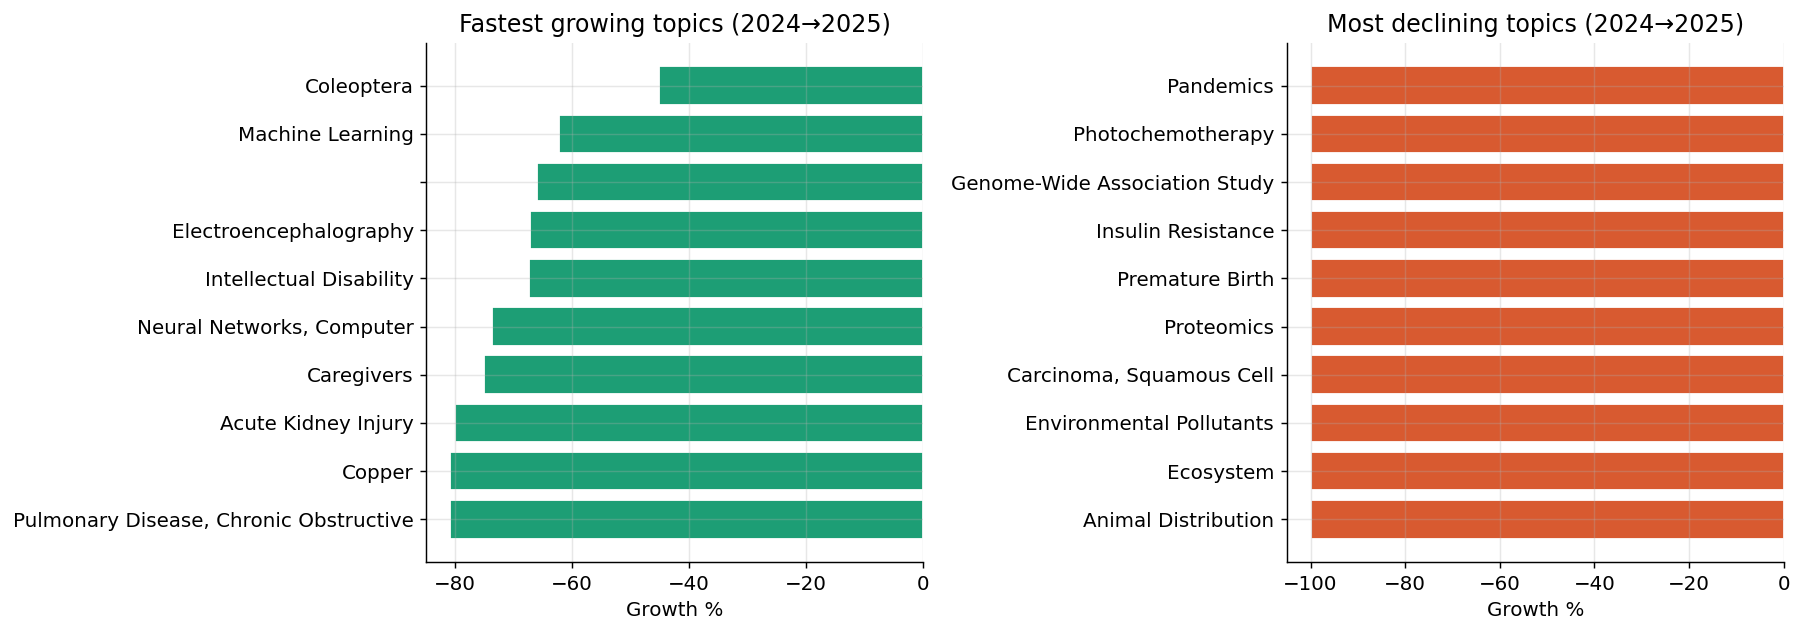

In [22]:
#  Topic growth rate (2024 vs 2025) 
y24 = df[df['pub_year'] == 2024]['major_topic'].value_counts()
y25 = df[df['pub_year'] == 2025]['major_topic'].value_counts()

growth = pd.DataFrame({'2024': y24, '2025': y25}).fillna(0)
growth['growth_pct'] = ((growth['2025'] - growth['2024']) / growth['2024'].replace(0, np.nan)) * 100

# Top growing and declining topics
min_count = 50
growth_filtered = growth[growth['2024'] >= min_count].sort_values('growth_pct')

top10_growing  = growth_filtered.tail(10)
top10_decline  = growth_filtered.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top10_growing.index, top10_growing['growth_pct'], color=PALETTE[1], edgecolor='white')
axes[0].set_title('Fastest growing topics (2024→2025)')
axes[0].set_xlabel('Growth %')

axes[1].barh(top10_decline.index, top10_decline['growth_pct'], color=PALETTE[4], edgecolor='white')
axes[1].set_title('Most declining topics (2024→2025)')
axes[1].set_xlabel('Growth %')

plt.tight_layout()
plt.show()

In [23]:
#  BERTopic (optional | requires GPU for best results) 
RUN_BERTOPIC = False  # ← set True to run (takes ~5–15 min on CPU)

if RUN_BERTOPIC:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    sample_n = 10000
    docs = df['abstract'].sample(sample_n, random_state=42).tolist()

    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
    topic_model = BERTopic(
        embedding_model=embedding_model,
        nr_topics=50,
        verbose=True
    )
    topics, probs = topic_model.fit_transform(docs)

    print('\nTop topics:')
    print(topic_model.get_topic_info().head(15))

    # Visualise
    topic_model.visualize_topics().show()
else:
    print('BERTopic skipped. Set RUN_BERTOPIC=True to enable.')

BERTopic skipped. Set RUN_BERTOPIC=True to enable.


In [24]:
#  LDA Topic Modelling (sklearn) 
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 10
sample_df_lda = df.sample(min(15000, len(df)), random_state=42)

lda_vec = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=15,
    max_df=0.85
)
X_lda = lda_vec.fit_transform(sample_df_lda['abstract'])

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20, n_jobs=-1)
lda.fit(X_lda)

print(f'LDA trained on {len(sample_df_lda):,} abstracts | {n_topics} topics\n')
lda_terms = lda_vec.get_feature_names_out()

for i, comp in enumerate(lda.components_):
    top_words = [lda_terms[j] for j in comp.argsort()[-12:][::-1]]
    print(f'  Topic {i+1:02d}: {", ".join(top_words)}')

LDA trained on 15,000 abstracts | 10 topics

  Topic 01: tb, asthma, tuberculosis, adhd, aa, hair, si, ni, prognosis, probability, intake, recommended
  Topic 02: patients, group, 95, ci, 95 ci, risk, study, age, treatment, years, vs, 001
  Topic 03: properties, high, acid, surface, materials, energy, based, reaction, structure, water, activity, using
  Topic 04: cells, cell, expression, cancer, tumor, mice, protein, immune, induced, genes, therapeutic, treatment
  Topic 05: species, genes, gene, genome, genetic, resistance, sequencing, sp, samples, isolates, bacterial, host
  Topic 06: case, patient, rare, year old, old, diagnosis, surgical, year, report, cases, treatment, clinical
  Topic 07: soil, water, species, environmental, climate, pollution, emissions, carbon, plant, air, pm2, river
  Topic 08: model, learning, data, models, accuracy, method, based, performance, proposed, methods, using, images
  Topic 09: af, mi, myocardial, cad, myocardial infarction, atrial, infarction, tob

---
## 5. Country & Journal Insights <a id='5-geo'></a>

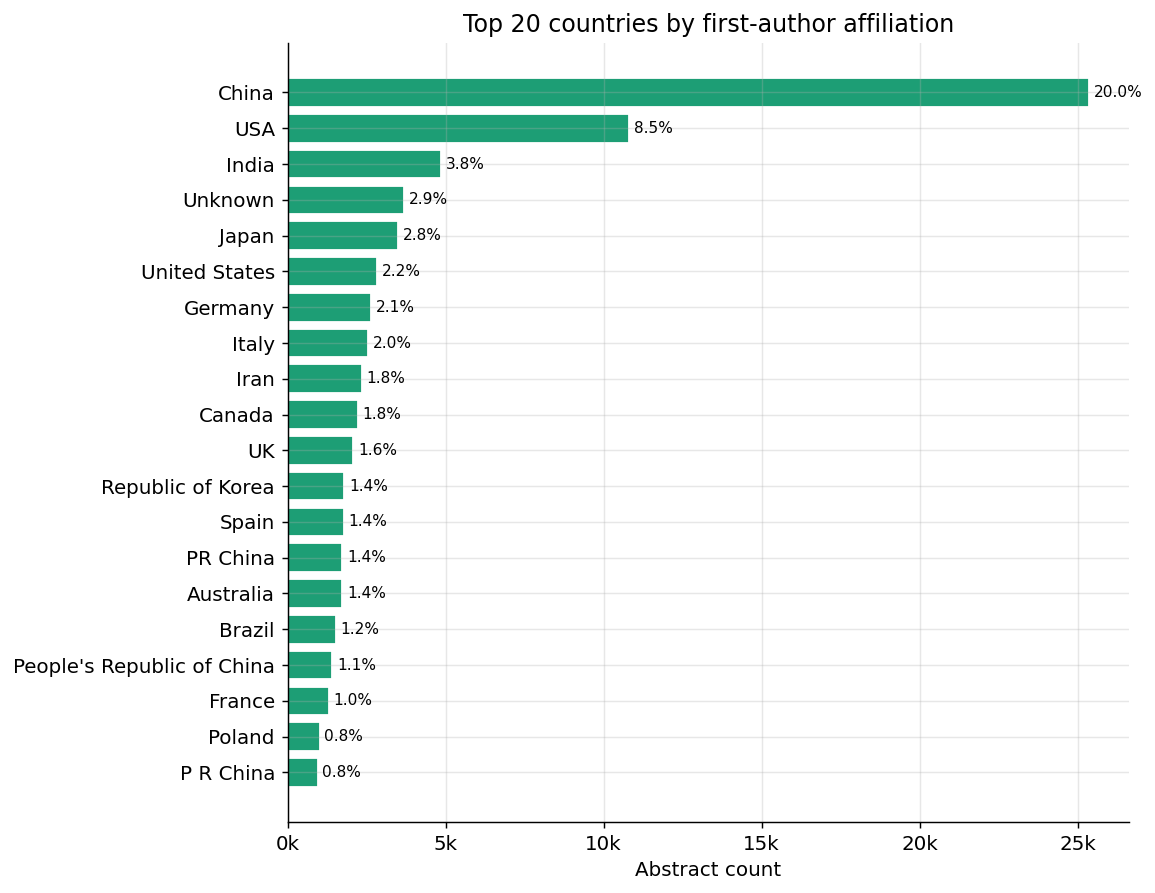

In [25]:
#  Country distribution 
country_counts = df['country'].value_counts()
top_countries  = country_counts.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=PALETTE[1], edgecolor='white')
ax.set_xlabel('Abstract count')
ax.set_title('Top 20 countries by first-author affiliation')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar, val in zip(bars, top_countries.values[::-1]):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

In [26]:
#  Choropleth world map (Plotly) 
try:
    import plotly.express as px

    country_df = country_counts.reset_index()
    country_df.columns = ['country', 'count']

    fig = px.choropleth(
        country_df,
        locations='country',
        locationmode='country names',
        color='count',
        color_continuous_scale='Blues',
        title='Global distribution of biomedical abstracts by country (2024–2026)',
        labels={'count': 'Abstracts'},
        width=950, height=480
    )
    fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    fig.show()
except ImportError:
    print('Plotly not installed. Run: pip install plotly')

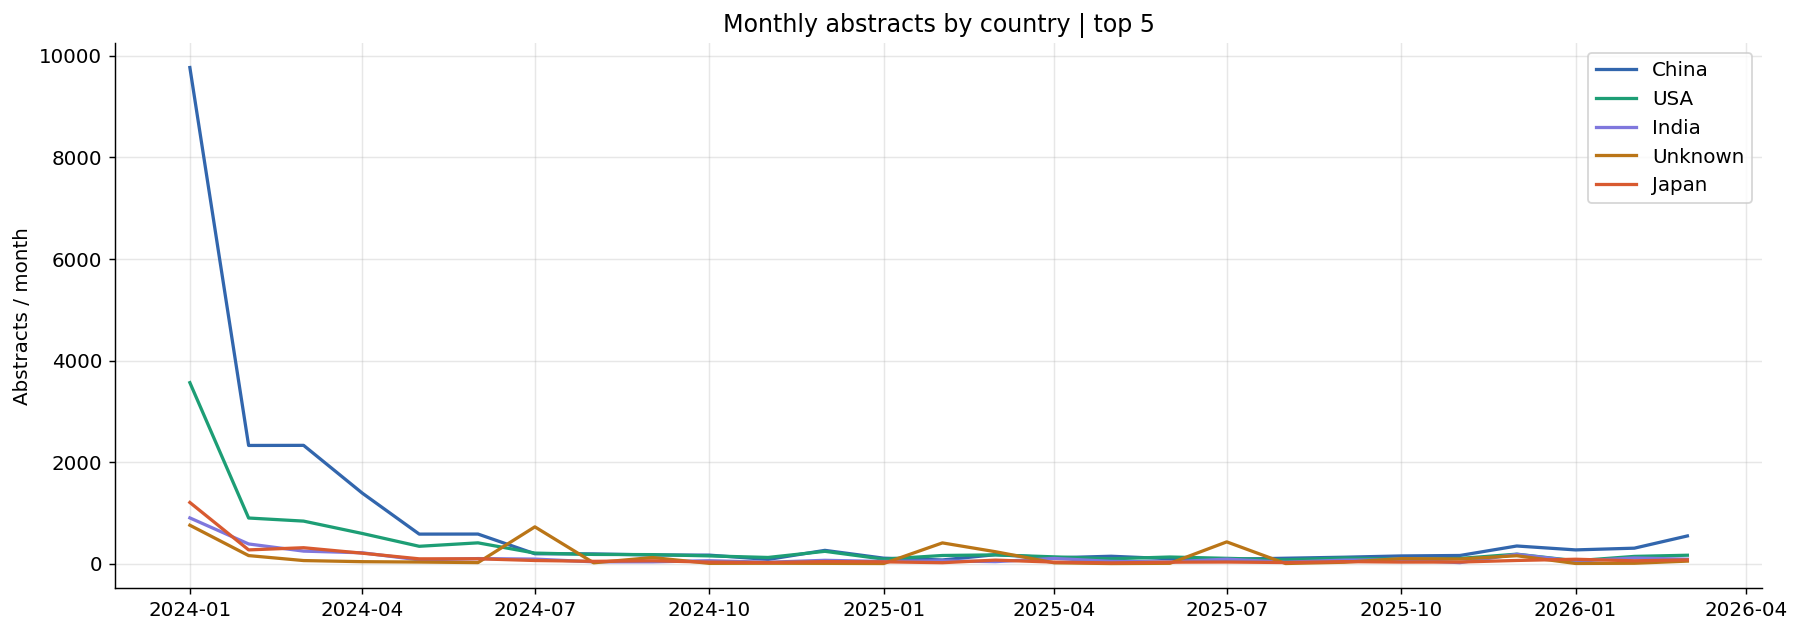

In [27]:
#  Country output over time (top 5) 
top5_countries = country_counts.head(5).index.tolist()
country_time   = (
    df[df['country'].isin(top5_countries)]
    .groupby(['date', 'country']).size()
    .reset_index(name='count')
)

fig, ax = plt.subplots(figsize=(14, 5))
for i, c in enumerate(top5_countries):
    sub = country_time[country_time['country'] == c].sort_values('date')
    ax.plot(sub['date'], sub['count'], label=c, color=PALETTE[i], linewidth=1.8)

ax.set_title('Monthly abstracts by country | top 5')
ax.set_ylabel('Abstracts / month')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
#  Journal concentration (Herfindahl Index) ─
journal_share = df['journal'].value_counts() / len(df)
hhi = (journal_share ** 2).sum()

print(f'Top 5 journals cover {journal_share.head(5).sum()*100:.1f}% of abstracts')
print(f'Top 10 journals cover {journal_share.head(10).sum()*100:.1f}% of abstracts')
print(f'Total unique journals: {df["journal"].nunique():,}')
print(f'Herfindahl-Hirschman Index (journal): {hhi:.4f}')
print('  (< 0.01 = very dispersed, 0.01–0.15 = moderate concentration)')

Top 5 journals cover 6.6% of abstracts
Top 10 journals cover 9.9% of abstracts
Total unique journals: 7,249
Herfindahl-Hirschman Index (journal): 0.0020
  (< 0.01 = very dispersed, 0.01–0.15 = moderate concentration)


In [29]:
#  Co-authorship: authors per paper by country ─
auth_country = (
    df[df['country'].isin(top5_countries)]
    .groupby('country')['authors_count']
    .agg(['mean', 'median', 'std'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print('Average authors per paper by country (top 5):')
print(auth_country)

Average authors per paper by country (top 5):
         mean  median   std
country                    
Japan    8.17     7.0  6.18
China    7.73     7.0  3.92
USA      7.22     6.0  5.68
Unknown  6.24     5.0  4.96
India    5.65     5.0  3.53


---
## 6. Open Access Analysis <a id='6-oa'></a>

Overall open-access rate: 65.8%  (83,473 / 126,832)


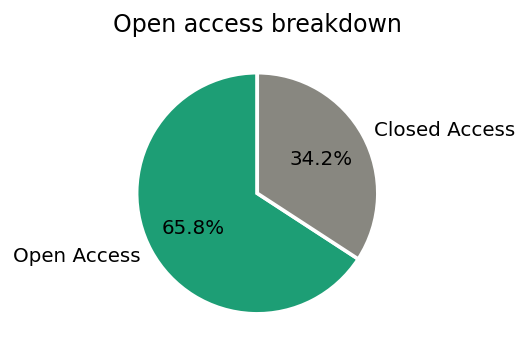

In [30]:
#  Overall OA rate 
oa_rate = df['open_access'].mean()
print(f'Overall open-access rate: {oa_rate*100:.1f}%  ({df["open_access"].sum():,} / {len(df):,})')

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(
    [oa_rate, 1 - oa_rate],
    labels=['Open Access', 'Closed Access'],
    colors=[PALETTE[1], PALETTE[5]],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Open access breakdown')
plt.tight_layout()
plt.show()

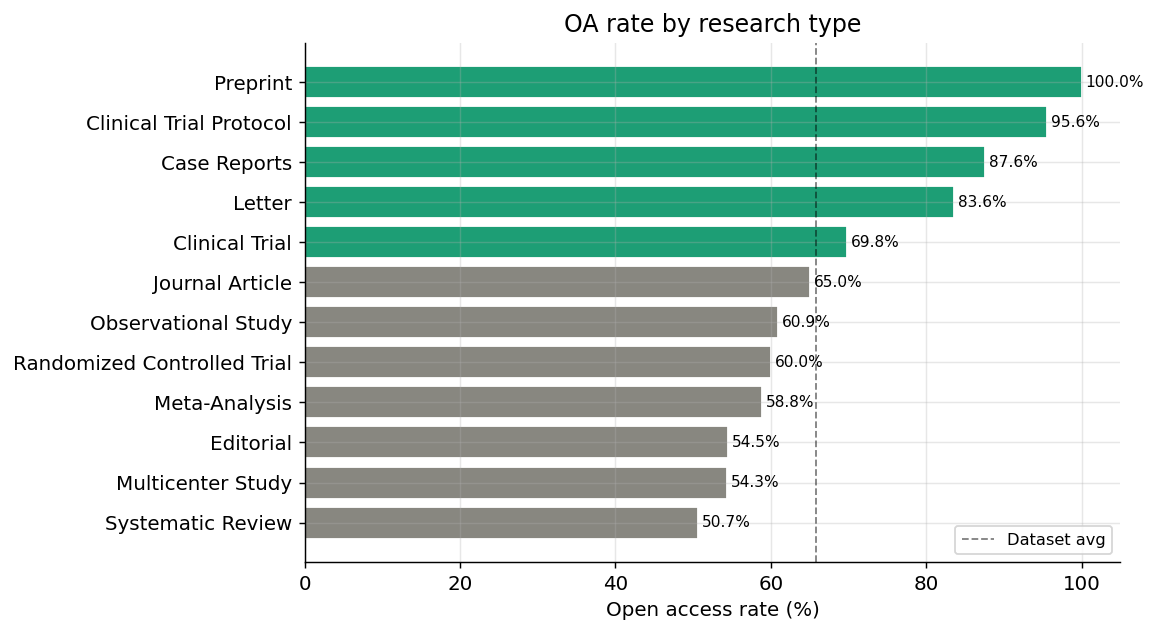

In [31]:
#  OA rate by research type 
type_series_oa = df.copy()
# Take primary type (first in the semicolon-separated string)
type_series_oa['primary_type'] = type_series_oa['research_type'].str.split(';').str[0].str.strip()

oa_by_type = (
    type_series_oa.groupby('primary_type')['open_access']
    .agg(['mean', 'count'])
    .query('count >= 100')
    .sort_values('mean', ascending=False)
    .head(12)
)
oa_by_type.columns = ['oa_rate', 'count']

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[1] if v >= oa_rate else PALETTE[5] for v in oa_by_type['oa_rate']]
bars = ax.barh(oa_by_type.index[::-1], oa_by_type['oa_rate'][::-1] * 100,
               color=colors[::-1], edgecolor='white')
ax.axvline(oa_rate * 100, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Dataset avg')
ax.set_xlabel('Open access rate (%)')
ax.set_title('OA rate by research type')
ax.legend(fontsize=9)
for bar, val in zip(bars, oa_by_type['oa_rate'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

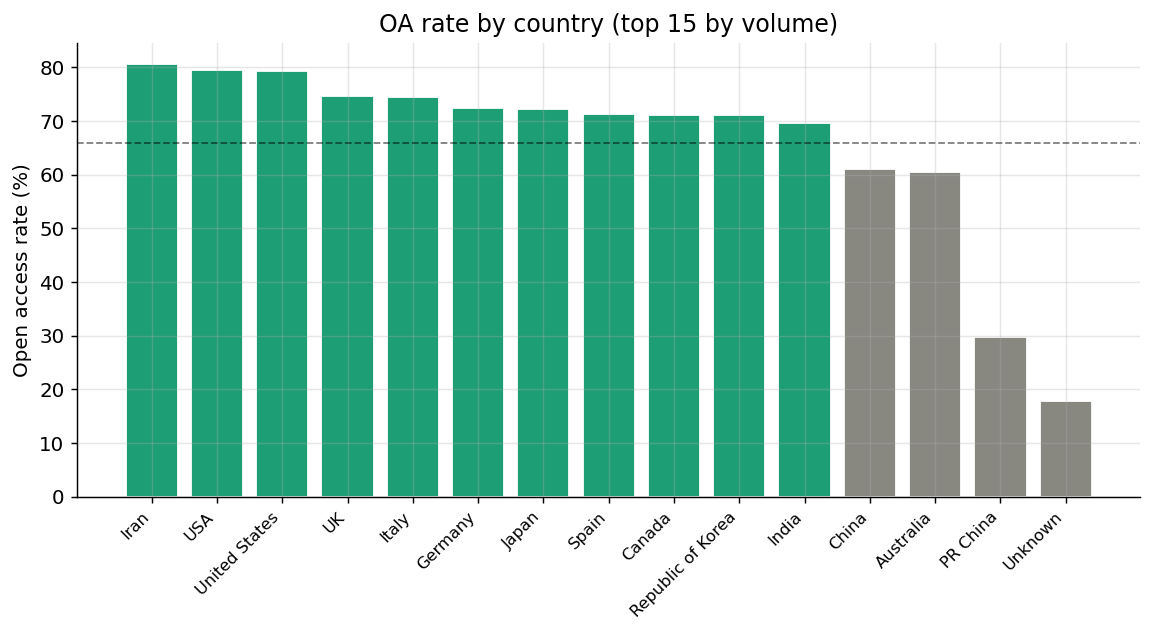

In [32]:
#  OA rate by top country ─
oa_by_country = (
    df[df['country'].isin(top_countries.head(15).index)]
    .groupby('country')['open_access']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
oa_by_country.columns = ['country', 'oa_rate']

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[1] if v >= oa_rate else PALETTE[5] for v in oa_by_country['oa_rate']]
ax.bar(oa_by_country['country'], oa_by_country['oa_rate'] * 100, color=colors, edgecolor='white')
ax.axhline(oa_rate * 100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticklabels(oa_by_country['country'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Open access rate (%)')
ax.set_title('OA rate by country (top 15 by volume)')
plt.tight_layout()
plt.show()

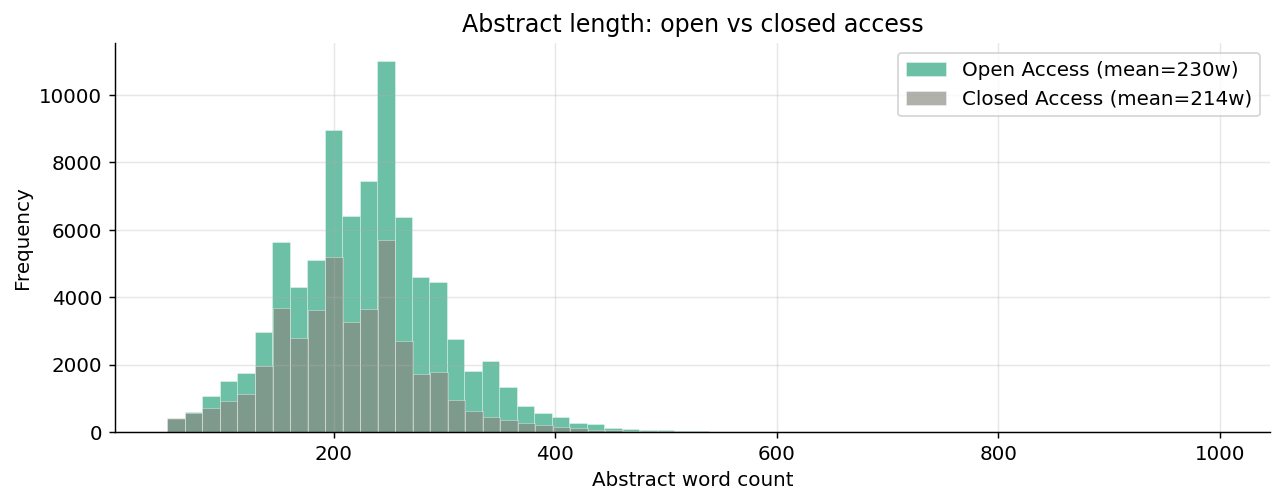

Mann-Whitney U test: statistic=2046018130, p-value=0.0000e+00
Statistically significant difference:


In [33]:
#  OA vs non-OA: abstract length comparison ─
oa_len    = df[df['open_access'] == True]['abstract_words'].dropna()
nonoa_len = df[df['open_access'] == False]['abstract_words'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(oa_len,    bins=60, alpha=0.65, label=f'Open Access (mean={oa_len.mean():.0f}w)',    color=PALETTE[1], edgecolor='white', linewidth=0.3)
ax.hist(nonoa_len, bins=60, alpha=0.65, label=f'Closed Access (mean={nonoa_len.mean():.0f}w)', color=PALETTE[5], edgecolor='white', linewidth=0.3)
ax.set_xlabel('Abstract word count')
ax.set_ylabel('Frequency')
ax.set_title('Abstract length: open vs closed access')
ax.legend()
plt.tight_layout()
plt.show()

from scipy import stats
t_stat, p_val = stats.mannwhitneyu(oa_len, nonoa_len, alternative='two-sided')
print(f'Mann-Whitney U test: statistic={t_stat:.0f}, p-value={p_val:.4e}')
print('Statistically significant difference:' if p_val < 0.05 else 'No significant difference')

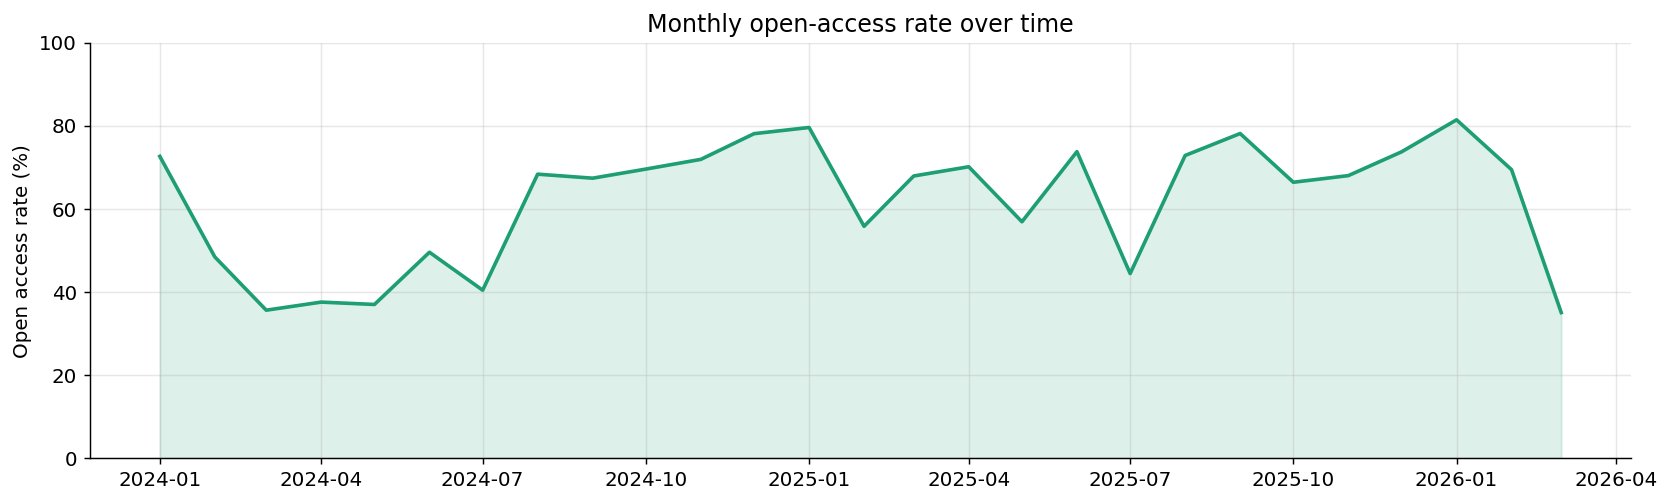

In [34]:
#  OA trend over time 
oa_time = df.groupby('date')['open_access'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(oa_time['date'], oa_time['open_access'] * 100, color=PALETTE[1], linewidth=2)
ax.fill_between(oa_time['date'], oa_time['open_access'] * 100, alpha=0.15, color=PALETTE[1])
ax.set_ylabel('Open access rate (%)')
ax.set_title('Monthly open-access rate over time')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

---
## 7. Machine Learning | Multi-label Classification <a id='7-ml'></a>

Class distribution BEFORE sampling:
primary_type
Journal Article    115957
Review                611
Name: count, dtype: int64

Train size: 24,000 | Test size: 6,000
Train class counts: {'Journal Article': 23872, 'Review': 128}

                 precision    recall  f1-score   support

Journal Article       1.00      0.99      0.99      5968
         Review       0.14      0.25      0.18        32

       accuracy                           0.99      6000
      macro avg       0.57      0.62      0.59      6000
   weighted avg       0.99      0.99      0.99      6000



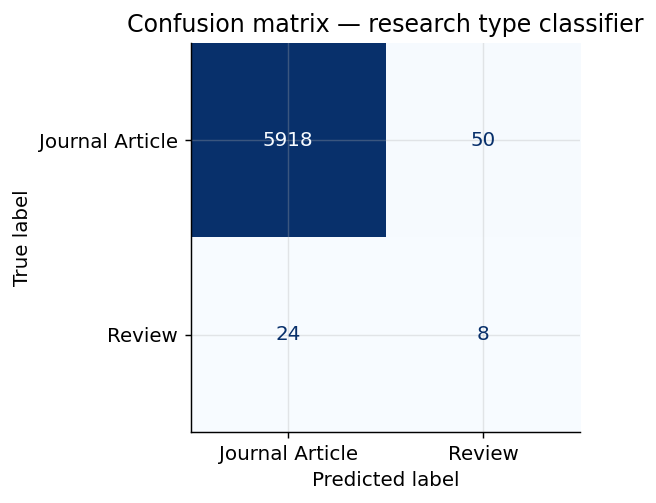

In [36]:
#  Predict research type from abstract (binary: Journal Article vs Review) ─
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

BINARY_TYPES = ['Journal Article', 'Review']

# research_type often contains multi-value strings e.g. "Journal Article; Review"
# Extract the PRIMARY type (first token) and filter to our two classes
clf_df = df.copy()
clf_df['primary_type'] = clf_df['research_type'].str.split(';').str[0].str.strip()
clf_df = clf_df[clf_df['primary_type'].isin(BINARY_TYPES)]

print("Class distribution BEFORE sampling:")
print(clf_df['primary_type'].value_counts())

# Guard: need at least 2 classes
assert clf_df['primary_type'].nunique() >= 2, (
    "Still only one class after extraction — check your research_type column values:\n"
    + str(df['research_type'].value_counts().head(10))
)

clf_df = clf_df.sample(min(30_000, len(clf_df)), random_state=42)

X = clf_df['abstract']
y = clf_df['primary_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,} | Test size: {len(X_test):,}")
print("Train class counts:", y_train.value_counts().to_dict())

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10_000, stop_words='english', ngram_range=(1, 2))),
    ('clf',   LogisticRegression(max_iter=500, C=1.0, class_weight='balanced', n_jobs=-1))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("\n" + classification_report(y_test, y_pred))

cm  = confusion_matrix(y_test, y_pred, labels=BINARY_TYPES)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=BINARY_TYPES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix — research type classifier')
plt.tight_layout()
plt.show()

In [37]:
#  Predict open_access from abstract features 
from sklearn.ensemble import GradientBoostingClassifier

oa_df = df.dropna(subset=['abstract_words', 'authors_count']).copy()
oa_df['primary_type'] = oa_df['research_type'].str.split(';').str[0].str.strip()

# Feature engineering
oa_df['country_top'] = oa_df['country'].apply(lambda x: x if x in top_countries.head(10).index else 'Other')
features = pd.get_dummies(
    oa_df[['abstract_words','authors_count','pub_year','pub_month_num','country_top','primary_type']],
    columns=['country_top','primary_type'],
    drop_first=False
)

X_oa = features.fillna(0)
y_oa = oa_df['open_access'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X_oa, y_oa, test_size=0.2, random_state=42, stratify=y_oa)

from sklearn.linear_model import LogisticRegression as LR
oa_clf = LR(max_iter=300, C=1.0)
oa_clf.fit(X_tr, y_tr)
y_oa_pred = oa_clf.predict(X_te)

print('Open-access prediction (structured features only):')
print(classification_report(y_te, y_oa_pred, target_names=['Closed','Open']))

Open-access prediction (structured features only):
              precision    recall  f1-score   support

      Closed       0.55      0.12      0.19      8672
        Open       0.67      0.95      0.79     16695

    accuracy                           0.66     25367
   macro avg       0.61      0.53      0.49     25367
weighted avg       0.63      0.66      0.58     25367



In [38]:
#  Imbalanced learning: handle temporal skew (80% 2024) 
from sklearn.utils import resample

print('Class distribution by year:')
print(df['pub_year'].value_counts().sort_index())
print()

# Undersample 2024 to balance with 2025
df_2024 = df[df['pub_year'] == 2024]
df_2025 = df[df['pub_year'] == 2025]
df_2026 = df[df['pub_year'] == 2026]

n_target = len(df_2025)  # balance to 2025 count

df_2024_down = resample(df_2024, replace=False, n_samples=n_target, random_state=42)
df_balanced  = pd.concat([df_2024_down, df_2025, df_2026]).sample(frac=1, random_state=42)

print(f'Balanced dataset: {len(df_balanced):,} rows')
print(df_balanced['pub_year'].value_counts().sort_index())
print('\nNote: For training on balanced data, use df_balanced instead of df.')

Class distribution by year:
pub_year
2024    101537
2025     19591
2026      5704
Name: count, dtype: Int64

Balanced dataset: 44,886 rows
pub_year
2024    19591
2025    19591
2026     5704
Name: count, dtype: Int64

Note: For training on balanced data, use df_balanced instead of df.


---
## 8. Semantic Search with FAISS <a id='8-faiss'></a>

In [39]:
#  Build sentence embedding index 


RUN_SEMANTIC = False  # ← set True (takes ~10–30 min for full dataset)

if RUN_SEMANTIC:
    import faiss
    from sentence_transformers import SentenceTransformer

    EMBED_MODEL = 'all-MiniLM-L6-v2'   # fast; swap for 'pritamdeka/S-PubMedBert-MS-MARCO' for biomedical
    SAMPLE_N    = 20000                  # reduce for quick demo

    print(f'Loading model: {EMBED_MODEL}')
    embedder = SentenceTransformer(EMBED_MODEL)

    sample_docs = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
    texts       = (sample_docs['title'] + '. ' + sample_docs['abstract']).tolist()

    print(f'Encoding {SAMPLE_N:,} documents…')
    embeddings = embedder.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)

    # L2-normalise → inner product == cosine similarity
    faiss.normalize_L2(embeddings)

    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    print(f'FAISS index built: {index.ntotal:,} vectors, dim={dim}')

    def semantic_search(query, top_k=5):
        q_emb = embedder.encode([query], convert_to_numpy=True)
        faiss.normalize_L2(q_emb)
        scores, indices = index.search(q_emb, top_k)
        hits = sample_docs.iloc[indices[0]].copy()
        hits['score'] = scores[0]
        return hits[['score','title','journal','pub_year','country','open_access']]

    # Demo
    print('\nQuery: "CRISPR gene therapy muscular dystrophy"')
    print(semantic_search('CRISPR gene therapy muscular dystrophy').to_string(index=False))

    # Save index for reuse
    faiss.write_index(index, 'biomedical_faiss.index')
    sample_docs.to_parquet('biomedical_faiss_meta.parquet')
    print('\n Index saved to disk.')

else:
    print('Semantic search skipped. Set RUN_SEMANTIC=True to enable.')

Semantic search skipped. Set RUN_SEMANTIC=True to enable.


---
## 9. Temporal Trend Analysis <a id='9-temporal'></a>

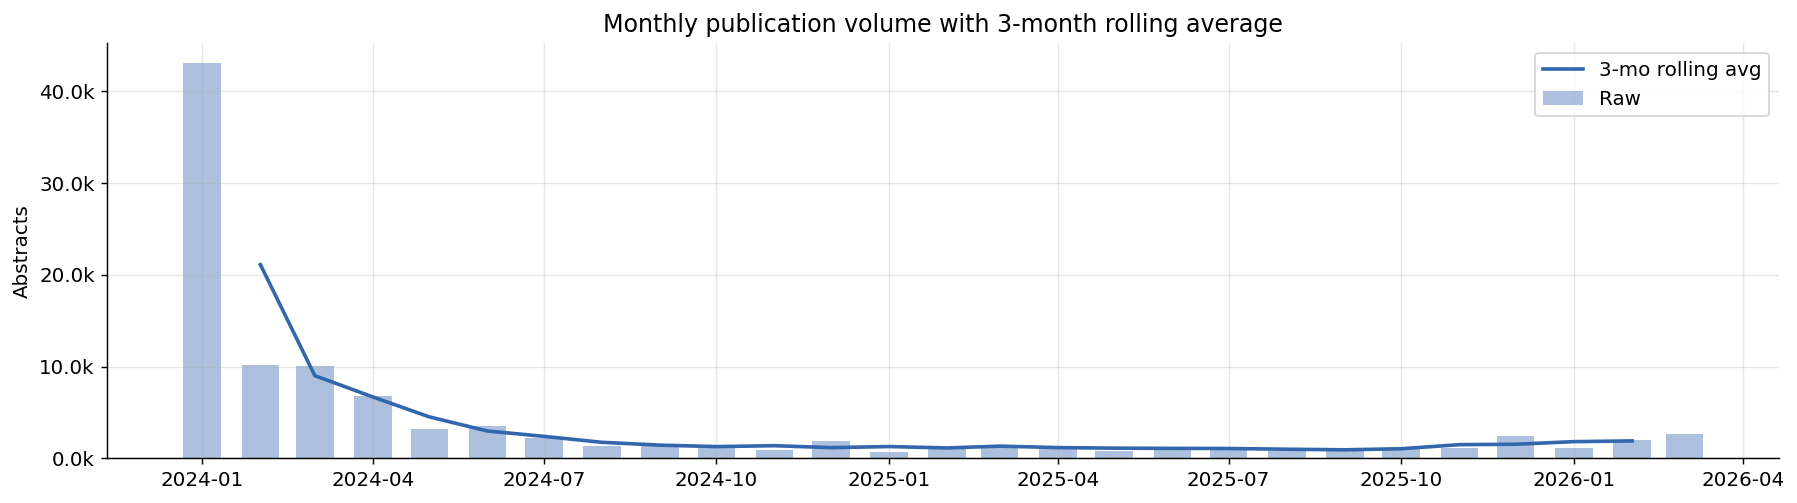

In [40]:
#  Rolling 3-month average publication volume 
monthly_all = df.groupby('date').size().reset_index(name='count').sort_values('date')
monthly_all['rolling3'] = monthly_all['count'].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_all['date'], monthly_all['count'], width=20, alpha=0.4, color=PALETTE[0], label='Raw')
ax.plot(monthly_all['date'], monthly_all['rolling3'], color=PALETTE[0], linewidth=2, label='3-mo rolling avg')
ax.set_title('Monthly publication volume with 3-month rolling average')
ax.set_ylabel('Abstracts')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
plt.tight_layout()
plt.show()

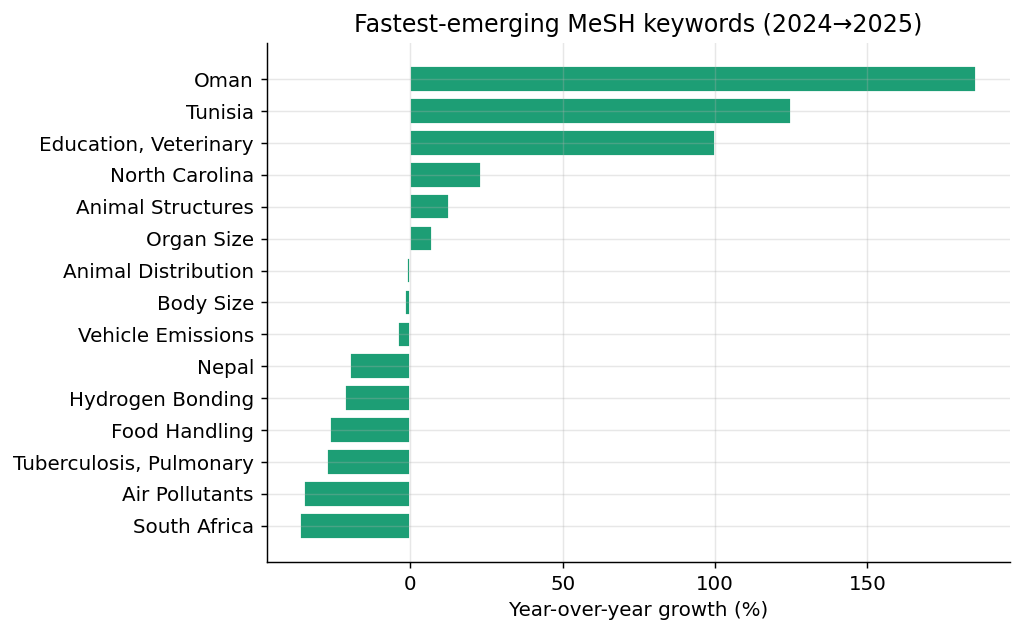

In [41]:
#  Year-over-year keyword emergence 
def keyword_freq_by_year(year):
    kw_list = df[df['pub_year'] == year]['keywords'].dropna()
    all_kw  = [k.strip() for row in kw_list for k in row.split(';') if k.strip()]
    return Counter(all_kw)

kw_2024 = keyword_freq_by_year(2024)
kw_2025 = keyword_freq_by_year(2025)

# Emerging keywords (high 2025, low 2024)
min_count = 20
emerging = {
    kw: (kw_2025[kw] / max(kw_2024[kw], 1) - 1)
    for kw in kw_2025
    if kw_2025[kw] >= min_count and kw_2024[kw] >= 5
}
top_emerging = sorted(emerging.items(), key=lambda x: x[1], reverse=True)[:15]

kws, rates = zip(*top_emerging)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(kws)[::-1], [r*100 for r in rates[::-1]], color=PALETTE[1], edgecolor='white')
ax.set_xlabel('Year-over-year growth (%)')
ax.set_title('Fastest-emerging MeSH keywords (2024→2025)')
plt.tight_layout()
plt.show()

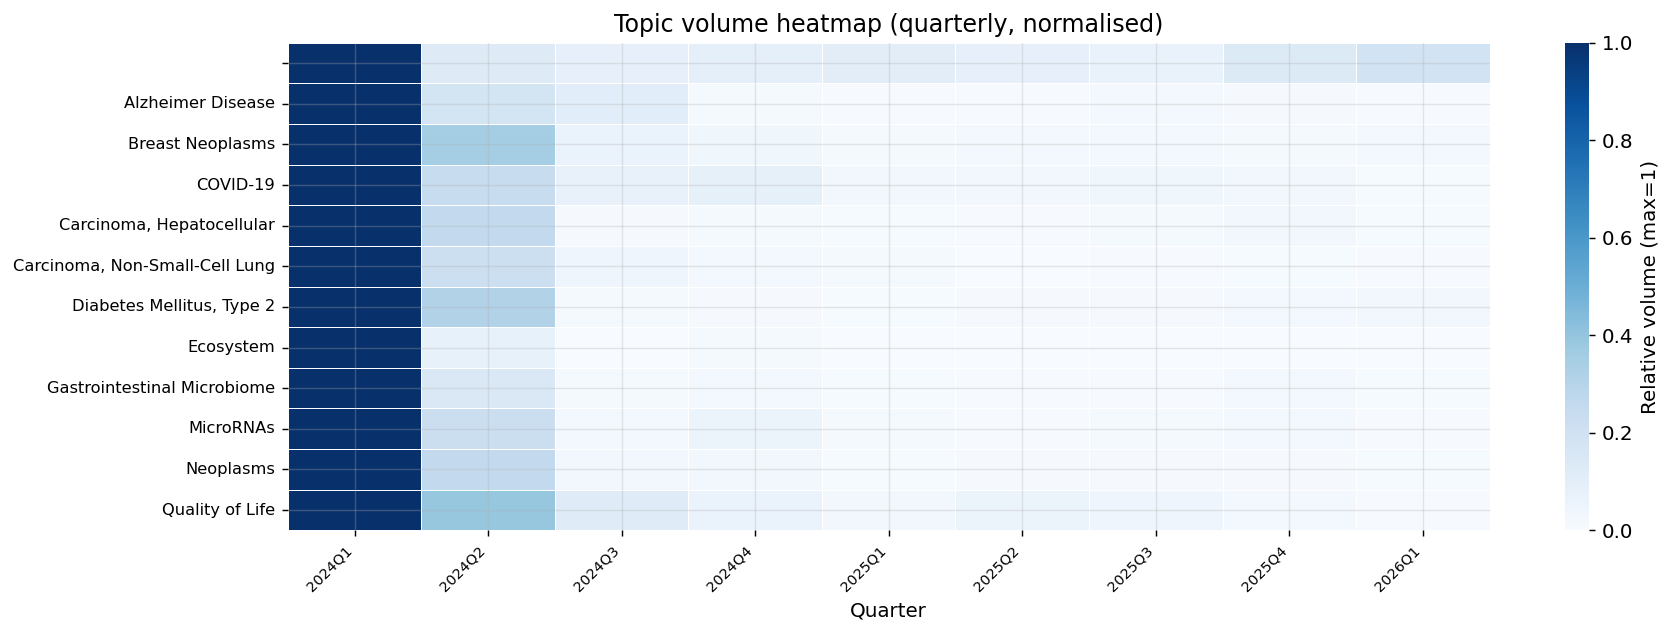

In [42]:
#  Heatmap: topic × month ─
TOP_N_HM   = 12
top_topics_list = df['major_topic'].value_counts().head(TOP_N_HM).index.tolist()

hm_df = (
    df[df['major_topic'].isin(top_topics_list)]
    .groupby(['major_topic', df['date'].dt.to_period('Q')])
    .size()
    .unstack(fill_value=0)
)

# Normalise per topic (show relative share)
hm_norm = hm_df.div(hm_df.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    hm_norm,
    ax=ax,
    cmap='Blues',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Relative volume (max=1)'}
)
ax.set_title('Topic volume heatmap (quarterly, normalised)')
ax.set_ylabel('')
ax.set_xlabel('Quarter')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Export & Summary <a id='10-export'></a>

In [43]:
#  Save enriched dataset 
SAVE_ENRICHED = True

if SAVE_ENRICHED:
    out = df.copy()
    out['primary_type'] = out['research_type'].str.split(';').str[0].str.strip()
    out['year_month']   = out['date'].dt.to_period('M').astype(str)
    out['abstract_len_bucket'] = pd.cut(
        out['abstract_words'],
        bins=[0, 100, 200, 300, 500, 1001],
        labels=['very_short','short','medium','long','very_long']
    )
    out.to_parquet('biomedical_abstracts_enriched.parquet', index=False)
    print(f' Saved enriched dataset: biomedical_abstracts_enriched.parquet ({out.shape})')

 Saved enriched dataset: biomedical_abstracts_enriched.parquet ((126832, 21))


In [45]:


print('  BIOMEDICAL ABSTRACTS 2024–2026 | ANALYSIS SUMMARY')

print(f'  Total abstracts analysed : {len(df):,}')
print(f'  Date range               : {df["date"].min().strftime("%b %Y")} – {df["date"].max().strftime("%b %Y")}')
print(f'  Journals                 : {df["journal"].nunique():,}')
print(f'  Countries                : {df["country"].nunique():,}')
print(f'  Open access rate         : {df["open_access"].mean()*100:.1f}%')
print(f'  Avg abstract length      : {df["abstract_words"].mean():.0f} words')
print(f'  Top country              : {df["country"].value_counts().index[0]}')
print(f'  Top journal              : {df["journal"].value_counts().index[0]}')



  BIOMEDICAL ABSTRACTS 2024–2026 | ANALYSIS SUMMARY
  Total abstracts analysed : 126,832
  Date range               : Jan 2024 – Mar 2026
  Journals                 : 7,249
  Countries                : 22,336
  Open access rate         : 65.8%
  Avg abstract length      : 224 words
  Top country              : China
  Top journal              : Scientific reports
